
[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01: Train Loss 0.4832, Val Acc 0.9195, Val F1 0.9148
Epoch 02: Train Loss 0.1489, Val Acc 0.9671, Val F1 0.9654
Epoch 03: Train Loss 0.0928, Val Acc 0.9300, Val F1 0.9270
Epoch 04: Train Loss 0.0873, Val Acc 0.9349, Val F1 0.9322
Epoch 05: Train Loss 0.0522, Val Acc 0.9713, Val F1 0.9694
Epoch 06: Train Loss 0.0620, Val Acc 0.9685, Val F1 0.9669
Epoch 07: Train Loss 0.0363, Val Acc 0.9615, Val F1 0.9587


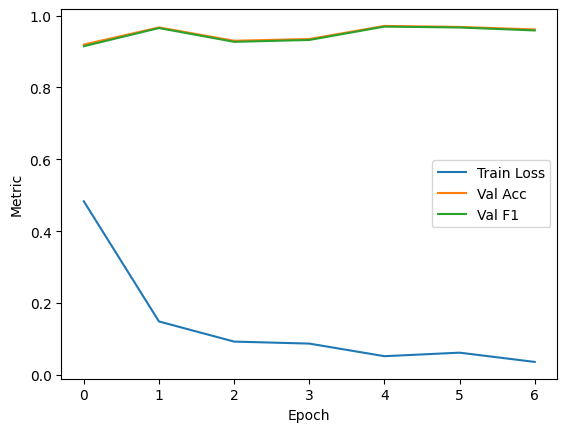

C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12896\572600691.py:119: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()


Test Acc: 0.965675057208238
Test F1: 0.9645638409994846
Test ROC AUC: 0.9965272504223714
              precision    recall  f1-score   support

      glioma       0.97      0.99      0.98       300
  meningioma       0.97      0.89      0.93       306
     notumor       0.96      0.99      0.97       405
   pituitary       0.97      0.99      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311



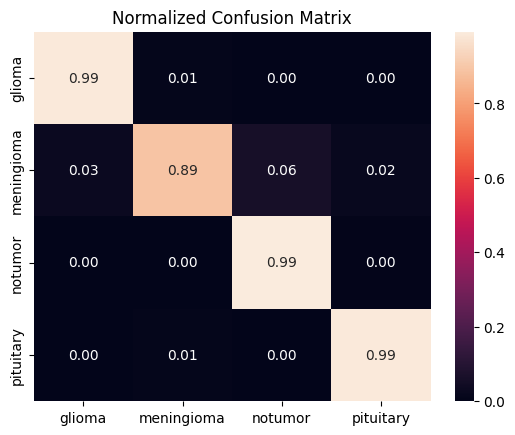

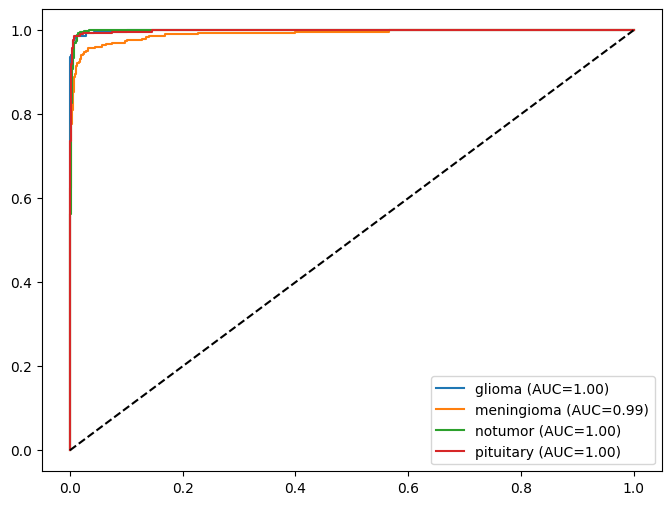

In [1]:
# 📦 Install Dependencies
!pip install -q transformers timm einops openpyxl

import os, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt, seaborn as sns, pandas as pd

from transformers import AutoImageProcessor, Dinov2ForImageClassification

# 🧠 Setup Device & Seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if device.type=='cuda': torch.cuda.manual_seed_all(s)
set_seed()
print("Device:", device)


# 🔧 Paths (update with your Drive's folder structure)
train_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Training'
test_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Testing'
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 🛠️ Load Processor + Model
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = Dinov2ForImageClassification.from_pretrained(
    "facebook/dinov2-base", num_labels=4
)
model.to(device)

# 🖼️ Transforms (Updated to fix KeyError)
image_size = processor.size if isinstance(processor.size, int) else processor.size["shortest_edge"]
tfm = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# 🗂️ Dataset Handling
def make_subset(path):
    ds = datasets.ImageFolder(path, transform=tfm)
    valid = [i for i,(_,l) in enumerate(ds.samples)
             if ds.classes[l] in class_names]
    return Subset(ds, valid)

train_full = make_subset(train_path)
test_ds = make_subset(test_path)
val_size = int(0.25 * len(train_full))
train_ds, val_ds = random_split(train_full, [len(train_full)-val_size, val_size])

loaders = {
    "train": DataLoader(train_ds, batch_size=16, shuffle=True),
    "val":   DataLoader(val_ds, batch_size=16),
    "test":  DataLoader(test_ds, batch_size=16)
}

# 🚀 Optimizer + Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)
criterion = nn.CrossEntropyLoss()

# 🔁 Training & Validation Functions
def run_epoch(loader, train=True):
    mode = model.train if train else model.eval
    mode()
    tot_loss, all_p, all_l = 0, [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(pixel_values=imgs).logits
        loss = criterion(logits, labels)
        if train:
            loss.backward(); optimizer.step()
        tot_loss += loss.item()
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())

    loss = tot_loss / len(loader)
    acc = accuracy_score(all_l, all_p)
    f1 = f1_score(all_l, all_p, average='macro')
    return loss, acc, f1

# 📈 Training Loop
history = {"train_loss":[], "val_acc":[], "val_f1":[]}

for epoch in range(1, 8):
    tl, _, _ = run_epoch(loaders["train"], train=True)
    vl, vacc, vf1 = run_epoch(loaders["val"], train=False)
    print(f"Epoch {epoch:02}: Train Loss {tl:.4f}, Val Acc {vacc:.4f}, Val F1 {vf1:.4f}")
    history["train_loss"].append(tl)
    history["val_acc"].append(vacc)
    history["val_f1"].append(vf1)

# 📊 Metrics Plot
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_acc"], label="Val Acc")
plt.plot(history["val_f1"], label="Val F1")
plt.xlabel("Epoch"); plt.ylabel("Metric")
plt.legend(); plt.show()

# 🧪 Test Set Evaluation
all_p, all_l, all_logits = [], [], []
model.eval()
with torch.no_grad():
    for imgs, labels in loaders["test"]:
        imgs = imgs.to(device)
        logits = model(pixel_values=imgs).logits
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())
        all_logits.extend(logits.cpu().numpy())

probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()
print("Test Acc:", accuracy_score(all_l, all_p))
print("Test F1:", f1_score(all_l, all_p, average='macro'))
print("Test ROC AUC:", roc_auc_score(all_l, probs, multi_class='ovr'))
print(classification_report(all_l, all_p, target_names=class_names))

# 🧩 Confusion Matrix
cm = confusion_matrix(all_l, all_p)
sns.heatmap(cm/cm.sum(axis=1,keepdims=True), annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.show()

# 🧭 ROC Curves
labels_bin = label_binarize(all_l, classes=list(range(4)))
plt.figure(figsize=(8,6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_bin[:,i], probs[:,i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.show()
    


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\JARE WORKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 01: Train Loss 0.4832, Val Acc 0.9195, Val F1 0.9148
Epoch 02: Train Loss 0.1489, Val Acc 0.9671, Val F1 0.9654
Epoch 03: Train Loss 0.0928, Val Acc 0.9300, Val F1 0.9270
Epoch 04: Train Loss 0.0873, Val Acc 0.9349, Val F1 0.9322
Epoch 05: Train Loss 0.0522, Val Acc 0.9713, Val F1 0.9694
Epoch 06: Train Loss 0.0620, Val Acc 0.9685, Val F1 0.9669
Epoch 07: Train Loss 0.0363, Val Acc 0.9615, Val F1 0.9587
Epoch 08: Train Loss 0.0449, Val Acc 0.9503, Val F1 0.9483
Epoch 09: Train Loss 0.0637, Val Acc 0.9671, Val F1 0.9655
Epoch 10: Train Loss 0.0462, Val Acc 0.9580, Val F1 0.9560


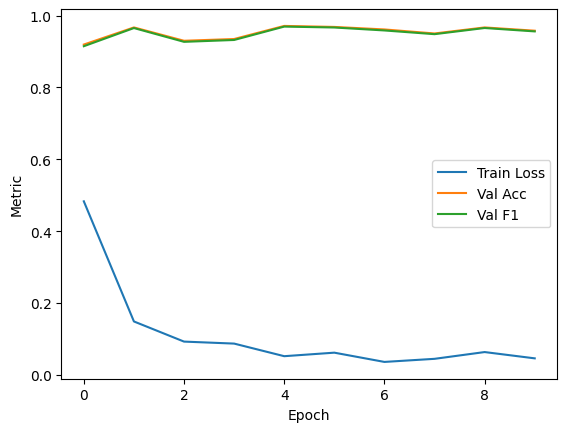

C:\Users\JARE WORKS\AppData\Local\Temp\ipykernel_12576\2438155612.py:119: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()


Test Acc: 0.958047292143402
Test F1: 0.9562442820923152
Test ROC AUC: 0.995131441922233
              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       300
  meningioma       0.88      0.98      0.93       306
     notumor       0.99      0.98      0.98       405
   pituitary       0.99      0.97      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



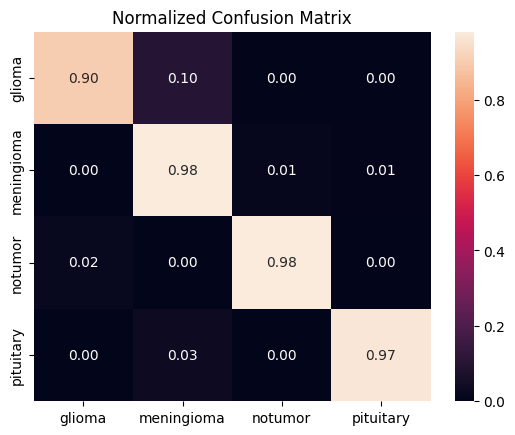

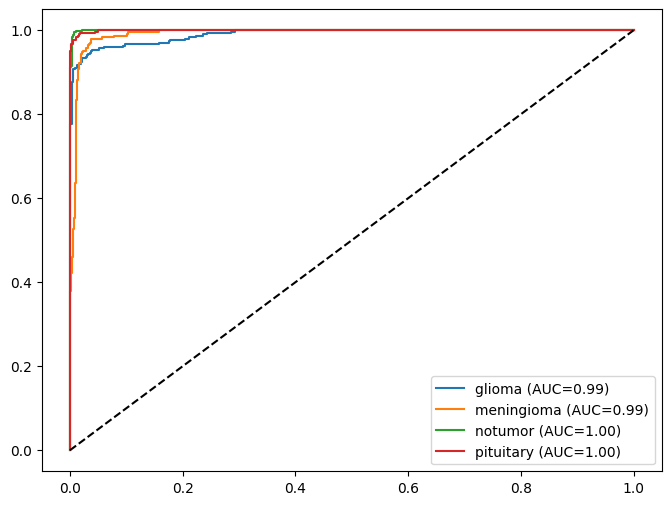

In [1]:
  # 📦 Install Dependencies
%pip install -q transformers timm einops openpyxl

import os, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt, seaborn as sns, pandas as pd

from transformers import AutoImageProcessor, Dinov2ForImageClassification

# 🧠 Setup Device & Seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if device.type=='cuda': torch.cuda.manual_seed_all(s)
set_seed()
print("Device:", device)


# 🔧 Paths (update with your Drive's folder structure)
train_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Training'
test_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Testing'
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 🛠️ Load Processor + Model
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = Dinov2ForImageClassification.from_pretrained(
    "facebook/dinov2-base", num_labels=4
)
model.to(device)

# 🖼️ Transforms (Updated to fix KeyError)
image_size = processor.size if isinstance(processor.size, int) else processor.size["shortest_edge"]
tfm = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# 🗂️ Dataset Handling
def make_subset(path):
    ds = datasets.ImageFolder(path, transform=tfm)
    valid = [i for i,(_,l) in enumerate(ds.samples)
             if ds.classes[l] in class_names]
    return Subset(ds, valid)

train_full = make_subset(train_path)
test_ds = make_subset(test_path)
val_size = int(0.25 * len(train_full))
train_ds, val_ds = random_split(train_full, [len(train_full)-val_size, val_size])

loaders = {
    "train": DataLoader(train_ds, batch_size=16, shuffle=True),
    "val":   DataLoader(val_ds, batch_size=16),
    "test":  DataLoader(test_ds, batch_size=16)
}

# 🚀 Optimizer + Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)
criterion = nn.CrossEntropyLoss()

# 🔁 Training & Validation Functions
def run_epoch(loader, train=True):
    mode = model.train if train else model.eval
    mode()
    tot_loss, all_p, all_l = 0, [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(pixel_values=imgs).logits
        loss = criterion(logits, labels)
        if train:
            loss.backward(); optimizer.step()
        tot_loss += loss.item()
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())

    loss = tot_loss / len(loader)
    acc = accuracy_score(all_l, all_p)
    f1 = f1_score(all_l, all_p, average='macro')
    return loss, acc, f1

# 📈 Training Loop
history = {"train_loss":[], "val_acc":[], "val_f1":[]}

for epoch in range(1, 11):
    tl, _, _ = run_epoch(loaders["train"], train=True)
    vl, vacc, vf1 = run_epoch(loaders["val"], train=False)
    print(f"Epoch {epoch:02}: Train Loss {tl:.4f}, Val Acc {vacc:.4f}, Val F1 {vf1:.4f}")
    history["train_loss"].append(tl)
    history["val_acc"].append(vacc)
    history["val_f1"].append(vf1)

# 📊 Metrics Plot
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_acc"], label="Val Acc")
plt.plot(history["val_f1"], label="Val F1")
plt.xlabel("Epoch"); plt.ylabel("Metric")
plt.legend(); plt.show()

# 🧪 Test Set Evaluation
all_p, all_l, all_logits = [], [], []
model.eval()
with torch.no_grad():
    for imgs, labels in loaders["test"]:
        imgs = imgs.to(device)
        logits = model(pixel_values=imgs).logits
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())
        all_logits.extend(logits.cpu().numpy())

probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()
print("Test Acc:", accuracy_score(all_l, all_p))
print("Test F1:", f1_score(all_l, all_p, average='macro'))
print("Test ROC AUC:", roc_auc_score(all_l, probs, multi_class='ovr'))
print(classification_report(all_l, all_p, target_names=class_names))

# 🧩 Confusion Matrix
cm = confusion_matrix(all_l, all_p)
sns.heatmap(cm/cm.sum(axis=1,keepdims=True), annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.show()

# 🧭 ROC Curves
labels_bin = label_binarize(all_l, classes=list(range(4)))
plt.figure(figsize=(8,6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_bin[:,i], probs[:,i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.show()
    

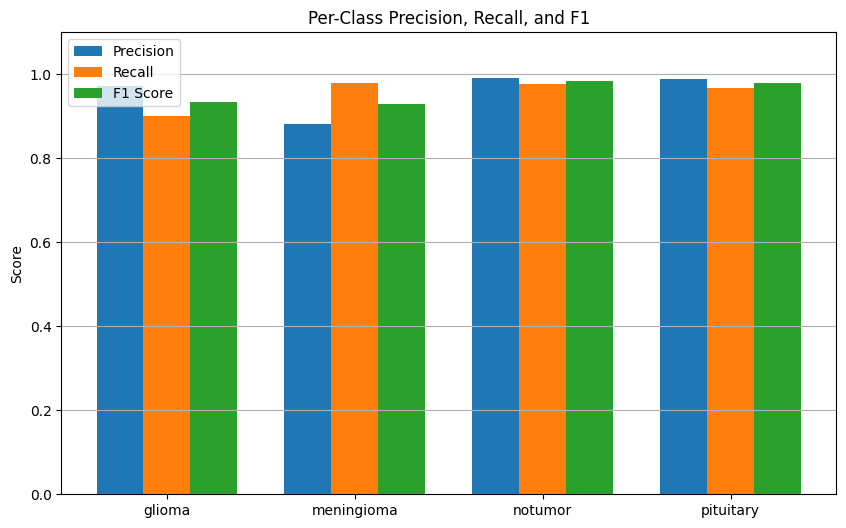

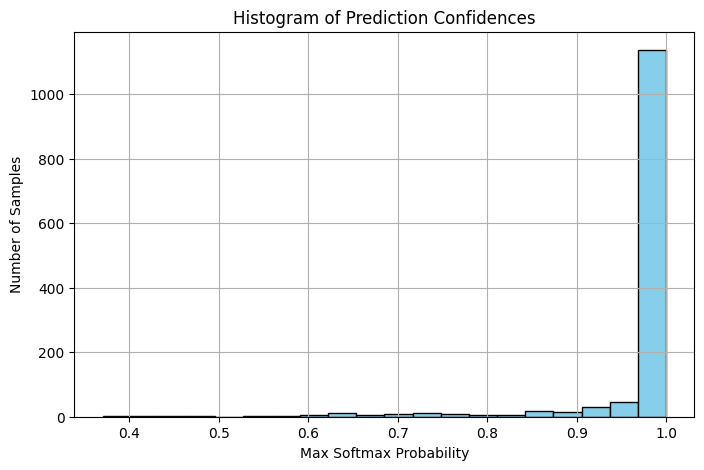

Showing 6 misclassified examples...


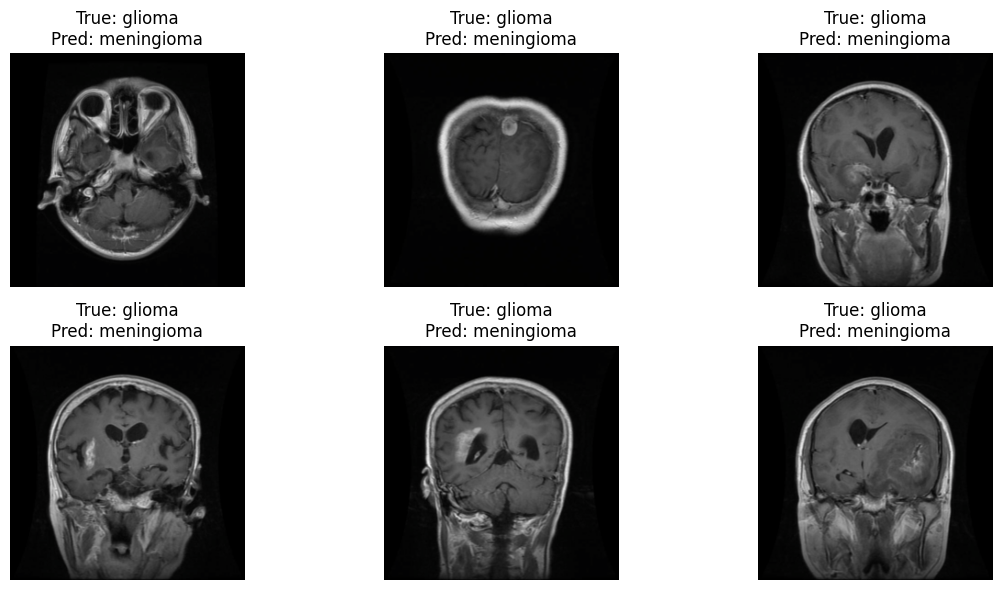

In [5]:
# 📊 Per-Class Metrics, Confidence Histogram, and Misclassified Samples

from sklearn.metrics import precision_score, recall_score

# -- Per-Class Precision, Recall, and F1
precision_vals = precision_score(all_l, all_p, average=None)
recall_vals = recall_score(all_l, all_p, average=None)
f1_vals = f1_score(all_l, all_p, average=None)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, precision_vals, width, label='Precision')
plt.bar(x, recall_vals, width, label='Recall')
plt.bar(x + width, f1_vals, width, label='F1 Score')
plt.xticks(x, class_names)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.ylim(0, 1.1)
plt.grid(True, axis='y')
plt.legend()
plt.show()

# -- Confidence Histogram (Max Softmax Probability)
max_probs = np.max(probs, axis=1)
plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Prediction Confidences")
plt.xlabel("Max Softmax Probability")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# -- Misclassified Samples
misclassified_indices = [i for i, (p, l) in enumerate(zip(all_p, all_l)) if p != l]
if misclassified_indices:
    print(f"Showing {min(6, len(misclassified_indices))} misclassified examples...")
    misclassified_subset = Subset(test_ds, misclassified_indices[:6])
    mis_loader = DataLoader(misclassified_subset, batch_size=6, shuffle=False)

    images, labels = next(iter(mis_loader))
    images = images.to(device)
    outputs = model(pixel_values=images).logits
    preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(2, 3, i + 1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        # Denormalize using processor's stats
        mean = np.array(processor.image_mean)
        std = np.array(processor.image_std)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


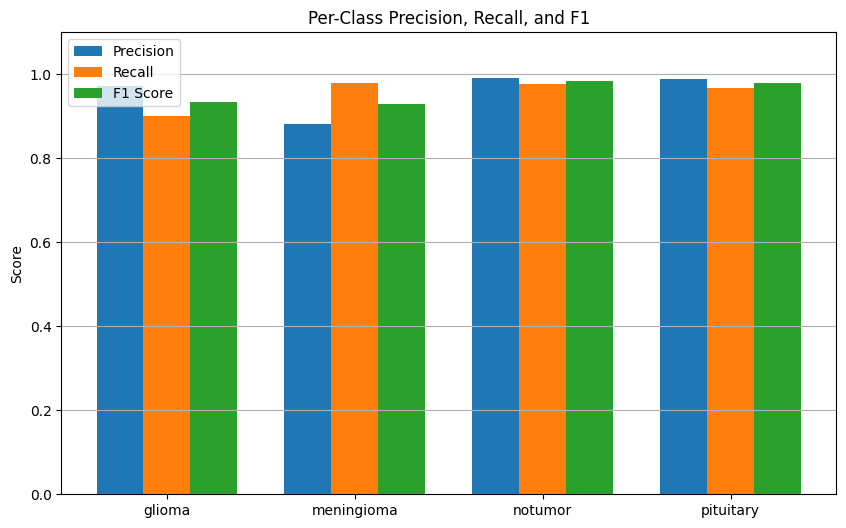

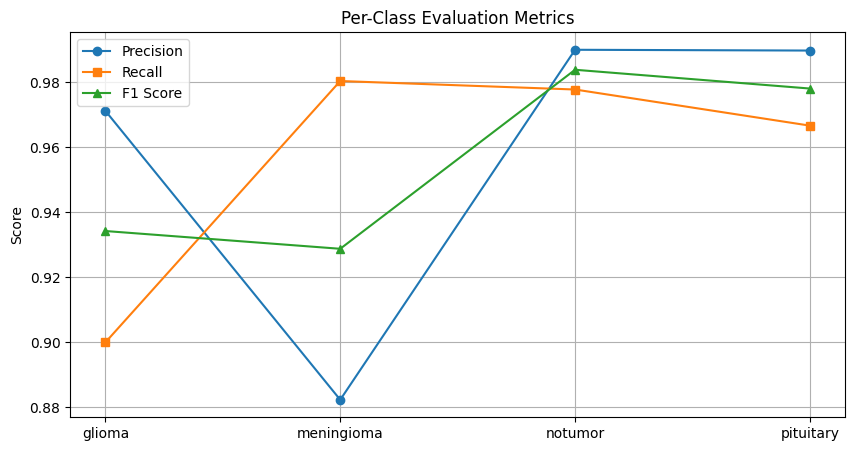

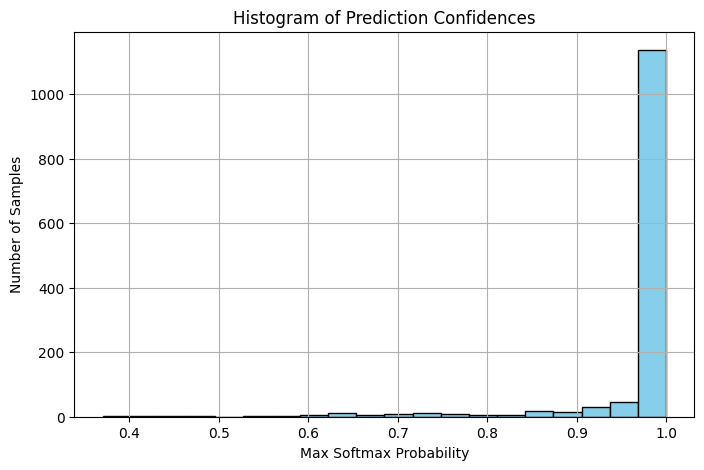

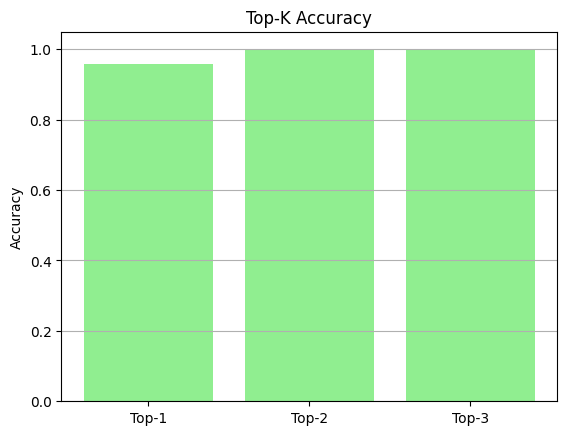

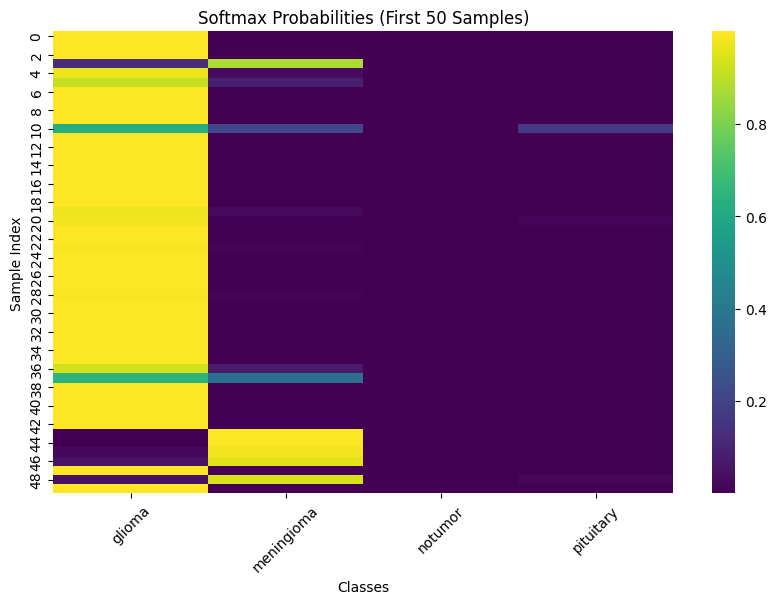

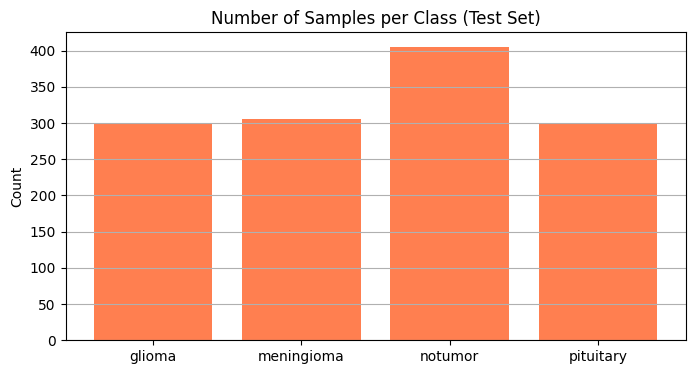

Showing 6 misclassified examples...


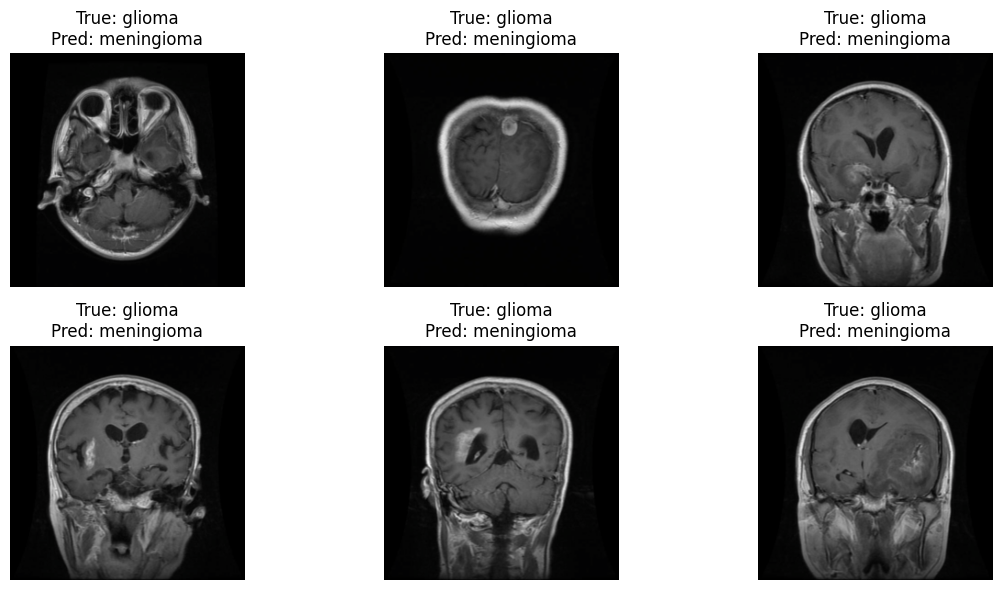

In [6]:
from sklearn.metrics import precision_score, recall_score
from sklearn.utils.multiclass import unique_labels

# ======= Per-Class Metrics (Precision, Recall, F1) =======
precision_vals = precision_score(all_l, all_p, average=None)
recall_vals = recall_score(all_l, all_p, average=None)
f1_vals = f1_score(all_l, all_p, average=None)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, precision_vals, width, label='Precision')
plt.bar(x, recall_vals, width, label='Recall')
plt.bar(x + width, f1_vals, width, label='F1 Score')
plt.xticks(x, class_names)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.ylim(0, 1.1)
plt.grid(True, axis='y')
plt.legend()
plt.show()

# ======= Per-Class Line Plot of Scores =======
plt.figure(figsize=(10, 5))
plt.plot(class_names, precision_vals, marker='o', label='Precision')
plt.plot(class_names, recall_vals, marker='s', label='Recall')
plt.plot(class_names, f1_vals, marker='^', label='F1 Score')
plt.ylabel("Score")
plt.title("Per-Class Evaluation Metrics")
plt.grid(True)
plt.legend()
plt.show()

# ======= Confidence Histogram =======
max_probs = np.max(probs, axis=1)
plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Prediction Confidences")
plt.xlabel("Max Softmax Probability")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# ======= Top-K Accuracy =======
topk = [1, 2, 3]
topk_correct = {k: 0 for k in topk}
total = len(all_l)
all_logits_tensor = torch.tensor(all_logits)

for i in range(total):
    true_label = all_l[i]
    top_preds = torch.topk(all_logits_tensor[i], max(topk)).indices.numpy()
    for k in topk:
        if true_label in top_preds[:k]:
            topk_correct[k] += 1

topk_acc = [topk_correct[k] / total for k in topk]
plt.bar([f"Top-{k}" for k in topk], topk_acc, color="lightgreen")
plt.ylim(0, 1.05)
plt.title("Top-K Accuracy")
plt.ylabel("Accuracy")
plt.grid(True, axis='y')
plt.show()

# ======= Heatmap of Softmax Scores =======
plt.figure(figsize=(10, 6))
sns.heatmap(probs[:50], cmap="viridis", cbar=True)
plt.title("Softmax Probabilities (First 50 Samples)")
plt.xlabel("Classes")
plt.ylabel("Sample Index")
plt.xticks(ticks=np.arange(len(class_names)) + 0.5, labels=class_names, rotation=45)
plt.show()

# ======= Class Support (Sample Counts per Class) =======
from collections import Counter
support_counts = Counter(all_l)
sample_counts = [support_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(8, 4))
plt.bar(class_names, sample_counts, color="coral")
plt.title("Number of Samples per Class (Test Set)")
plt.ylabel("Count")
plt.grid(True, axis='y')
plt.show()

# ======= Misclassified Samples (Up to 6) =======
misclassified_indices = [i for i, (p, l) in enumerate(zip(all_p, all_l)) if p != l]
if misclassified_indices:
    print(f"Showing {min(6, len(misclassified_indices))} misclassified examples...")
    misclassified_subset = Subset(test_ds, misclassified_indices[:6])
    mis_loader = DataLoader(misclassified_subset, batch_size=6, shuffle=False)

    images, labels = next(iter(mis_loader))
    images = images.to(device)
    outputs = model(pixel_values=images).logits
    preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(2, 3, i + 1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array(processor.image_mean)
        std = np.array(processor.image_std)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
